In [56]:
from langgraph.graph import StateGraph,START , END
from typing import TypedDict

In [57]:
class bmistate(TypedDict):
    weight_kg:float
    height_m:float
    bmi:float
    catogery:str

In [58]:
graph=StateGraph(bmistate)

In [59]:
def calculate_bmi(state:bmistate)->bmistate:
   height=  state['height_m']
   weight= state['weight_kg']
   bmi=weight/(height**2)
   state['bmi']=round(bmi,2)
   return state



In [60]:
def bmi_lable(state:bmistate)->bmistate:
    bmi=state["bmi"]
    if bmi < 18.5:
        state["catogery"]="Underweight"
    elif 18.5 <= bmi <= 24.9:
        state["catogery"]="Normal weight"
    elif 25 <= bmi <= 29.9:
        state["catogery"]="Overweight"
    else:
        state["catogery"]="Obese"
    
    return state

In [61]:
graph.add_node("Calculate_bmi",calculate_bmi)
graph.add_node("bmi_lable",bmi_lable)
graph.add_edge(START,"Calculate_bmi")
graph.add_edge("Calculate_bmi", "bmi_lable")
graph.add_edge("bmi_lable",END)


workflow=graph.compile()



In [62]:
intial_state={"weight_kg":90,'height_m':1.45}
output_state=workflow.invoke(intial_state)

In [63]:
output_state

{'weight_kg': 90, 'height_m': 1.45, 'bmi': 42.81, 'catogery': 'Obese'}

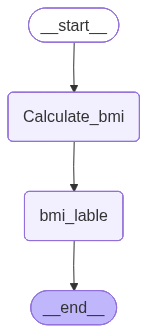

In [64]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())